# Heart Disease Classifier

This project aims to build a neural network that can accurately predict who has heart disease based on the data in the [UCI heart disease](https://archive.ics.uci.edu/dataset/45/heart+disease) dataset.

In [1144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F  # move data forward
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.stats import mannwhitneyu, chi2_contingency
from xgboost import XGBClassifier, plot_importance

## About the Data

There are 14 attributes in this dataset, some numerical and some categorical. 

The numerical values are:
- age in years 
    - range: >=0
    - older age means increased risk of heart disease as [arteries naturally stiffen, heart walls thicken, and valves calcify](https://cvhealthclinic.com/news/how-does-age-affect-heart-health/)
- resting blood pressure on admission to hospital (trestbps)
    - range: >0
    - consistently elevated resting bp forces the heart to work harder, increasing risk of heart disease
- serum cholesterol in mg/dl (chol)
    - range: >0
    - high serum cholesterol is linked to heart disease
- maximum heart rate achieved in beats per minute (bpm) during a maximal stress test (thalach)
    - range: >0
    - low maximum heart rate achieved during an exercise test for one's age can be correlated with presence of heart disease as the heart pumps less efficiently and may struggle to increase its rate under stress when there are blockages or restricted blood flow
- ST depression induced by exercise relative to rest (oldpeak)
    - range: R
    - ST segment in ECG represents the period when the ventricles of the heart are fully depolarized and preparing to repolarize (i.e. the ventricles are fully contracted, pumping blood out of the heart)
    - if ST segment is flat or depressed during the cardiac stress test, it typically means the heart isn't receiving enough oxygen (myocardial ischemia), indicating heart disease
    - if ST segment is upsloping during the cardiac stress test, it's not very specific as it can upslope as a side effect of exercise

    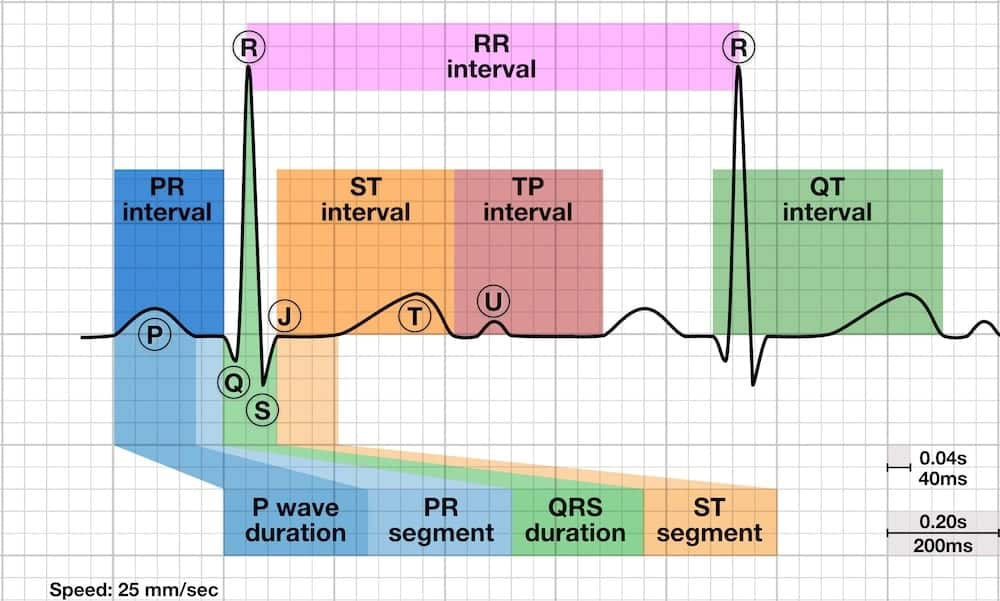
    - oldpeak is measured in mm or mV and quantifies how much the ST segment in an ECG dips below baseline during an exercise stress test compared to resting state (values > 1-2mm often point toward myocardial ischemia)
- number of major coronary vessels colored by fluoroscopy (ca)
    - range: 0-3
    - higher count generally indicates healthier blood flow and lower risk of heart disease
- diagnosis of heart disease (num)
    - range: 0-4
        - 0: No presence of heart disease.
        - 1: Mild or some presence of heart disease.
        - 2: Moderate presence of heart disease.
        - 3: Severe presence of heart disease.
        - 4: Very severe presence of heart disease.

The categorical values are:
- sex (male/female)
    - men typically experiences heart disease earlier than women and have higher overall rates, but women's risk sharply increases after menopause when estrogen levels drop
    - symptoms/indicators of heart disease can also differ between men and women
- chest pain type (cp: typical angina, atypical angina, non-anginal, asymptomatic)
    - typical angina: substernal chest discomfort (squeezing, pressure, fullness) that is predictably triggered by physical exertion or emotional stress and relieved by rest or nitroglycerin -> highest probability of heart disease
    - atypical angina: involves two of the typical angina characteristics but is often more diffuse; may present as pain radiating only to the back or jaw, sharp discomfort, or shortness of breath -> moderate probability of heart disease
    - non-anginal chest pain: does not meet the typical angina criteria; usually sharp, fleeting, or worsens with touch, breathing, or twisting -> low probability of heart disease and may be caused by other issues such as GERD, anxiety, or musculoskeletal issues
    - asymptomatic: lack of chest pain at all; must look at other attributes to determine heart disease risk
- fasting blood sugar > 120 mg/dl (fbs: T/F)
    - indicates prediabetes which significantly increases long-term risk of developing heat disease because if your body struggles to process glucose efficiently, it leads to excess glucose in the blood which causes blood vessels to become stiff and narrow over time
    - prediabetes also frequently occurs alongside other cardiac risk factors like high bp and unhealthy cholesterol levels
- resting echocardiographic results (restecg: normal, stt abnormality, or lv hypertrophy)
    - normal: heart's electrical system is functioning properly
    - stt abnormality: an abnormality in the ST-T wave portion of the ECG which represents ventricular repolarization (so there is an abnormality in ventricular repolarization)
        - ST segment represents when the ventricle is fully contracted and the T wave represents when the ventricle is relaxing
        - can indicate myocardial ischemia, high blood pressure (left ventricular hypertrophy), electrolyte imbalances, or a normal variant
    - lv hypertrophy (left ventricle hypertrophy) is the thickening of the heart's left ventricle which pumps oxygenated blood to the body, which stiffens the heart, greatly increasing risk of heart failure and arrhythmias
        - a consequence of ongoing heart disease and an independent risk factor for future cardiac events
- exercise induced angina (exang: T/F)
    - primary symptom of heart disease
- slope of the peak exercise ST segment (slope: upsloping, flat, or downsloping)
    - flat and downsloping during exercise indicates myocardial ischemia (explained above), upsloping during exercise is normal as the heart needs to work at a higher rate
- thallium stress test result (thal: normal, fixed defect, or reversible defect)
    - thallium stress test evaluates your heart's blood flow using a radioactive tracer and a gamma camera, tracking how well blood pumps through your heart:
        - normal result: even, healthy blood flow in all areas of the heart during rest and stress phases
        - reversible defect: blood flow is normal at rest but decreases during exercise or stress, indicating blocked or narrowed coronary artery
        - fixed defect: blood flow is reduced in certain areas of the heart during both rest and exercise; if no thallium is visible in a segment of the heart it typically means permanent damage or scarring from a previous heart attack

Also included are unique ids for each patient and the place where each patient was studied (origin), resulting in a total of 16 columns.

## Data Prep & Exploratory Analysis

### Load Data

In [1145]:
df = pd.read_csv('heart_disease_uci.csv')
df

,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [1146]:
(df['oldpeak'] < 0).any()

np.True_

### Check for missing values, duplicates, if all IDs are unqiue

In [1147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   origin    920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalach   865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [1148]:
df['fbs'] = df['fbs'].astype(str)
df['exang'] = df['exang'].astype(str)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   origin    920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    str    
 8   restecg   918 non-null    str    
 9   thalach   865 non-null    float64
 10  exang     865 non-null    str    
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), str(8)
memory usage: 115.1 KB


In [1149]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


In [1150]:
# check if all ids are unique
unique_id = df['id'].is_unique
print('\nUnique IDs:', unique_id)


Unique IDs: True


In [1151]:
print('Percentage of data missing')
(df.isna().mean() * 100).round(2).astype(str) + '%'

Percentage of data missing


id            0.0%
age           0.0%
sex           0.0%
origin        0.0%
cp            0.0%
trestbps     6.41%
chol         3.26%
fbs          9.78%
restecg      0.22%
thalach      5.98%
exang        5.98%
oldpeak      6.74%
slope       33.59%
ca          66.41%
thal        52.83%
num           0.0%
dtype: str

### Impute or drop rows/columns with missing data

#### Can we just drop or must we impute?

In [1152]:
pct_rows_with_missing = df.isna().any(axis=1).mean()
print(f"{pct_rows_with_missing * 100:.2f}% of rows have missing data")

67.50% of rows have missing data


Can't just drop all rows with missing data because that's more than half the data, defeating the purpose of using a dataset of this size. and neural networks need lots of data to train well (i.e. not overfit).

There are [3 kinds of missingness](https://www.kaggle.com/code/utkarshsaxenadn/handling-missing-values-mcar-mar-mnar) that affects whether we drop/impute missing data as well as the imputation method we choose:
- Missing Completely At Random (MCAR)
- Missing At Random (MAR)
- Missing Not At Random (MNAR)

#### 1. features that have near-complete data

In [1153]:
print(df['restecg'].value_counts())
df[df['restecg'].isna()]

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64


,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
571,572,55,Male,Hungary,typical angina,140.0,295.0,False,NaN,136.0,False,0.0,NaN,NaN,NaN,1
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1


Because restecg is missing in only 0.22% of the data (less than 1-2% of the data), we will drop the rows in which it is missing because it is likely missing completely at random (MCAR). We choose to drop the rows instead of replace the missing values with the mode because we'd artificially inflate the normal category, diluting clinical reality. 

In [1154]:
df = df.dropna(subset=['restecg'])
print('Number of rows with missing restecg:', df['restecg'].isna().sum())

Number of rows with missing restecg: 0


#### 2. features that are moderately missing (more than 1-2% of their values but less than 33-66%)

##### Prep data for imputation

The plan is to impute them using KNNImputer because it imputes missing values using the mean value from similar samples. But first, we have to identify which values to impute. Are they all already NaN or are there some out-of-range values that we also need to take care of?

In [1155]:
df.columns[df.eq(0).any()].tolist()

['trestbps', 'chol', 'oldpeak', 'ca', 'num']

trestbps and chol cannot be 0 if the patient is alive, so 0 values are mistakes. fbs and exang should be recorded as True/False in the csv, so if there is a 0, it's a mistake. 0 is an acceptable value for oldpeak, ca, and num.

In [1156]:
# for trestbps, chol, fbs, and exang, convert all 0s to NaN.
cols_to_NaN = ['trestbps', 'chol', 'fbs', 'exang']
df[cols_to_NaN] = df[cols_to_NaN].replace(0, np.nan)
df.columns[df.eq(0).any()].tolist()  # verify that 0s were replaced with NaN

['oldpeak', 'ca', 'num']

We have to convert columns with binary values to 0s and 1s because KNNImputer doesn't work on categorical variables. 

In [1157]:
df['fbs']

0       True
1      False
2      False
3      False
4      False
       ...  
915     True
916    False
917     True
918     True
919    False
Name: fbs, Length: 918, dtype: str

In [1158]:
df['exang']

0      False
1       True
2       True
3      False
4      False
       ...  
915    False
916      NaN
917    False
918      NaN
919     True
Name: exang, Length: 918, dtype: str

In [1159]:
bool_cols = ['fbs', 'exang']
df[bool_cols] = df[bool_cols].replace('True', 1)
df[bool_cols] = df[bool_cols].replace('False', 0)

In [1160]:
df['fbs']

0      1
1      0
2      0
3      0
4      0
      ..
915    1
916    0
917    1
918    1
919    0
Name: fbs, Length: 918, dtype: object

In [1161]:
df['exang']

0        0
1        1
2        1
3        0
4        0
      ... 
915      0
916    NaN
917      0
918    NaN
919      1
Name: exang, Length: 918, dtype: object

In [1162]:
df['sex']

0        Male
1        Male
2        Male
3        Male
4      Female
        ...  
915    Female
916      Male
917      Male
918      Male
919      Male
Name: sex, Length: 918, dtype: str

In [1163]:
df['sex'] = df['sex'].replace('Female', 0)
df['sex'] = df['sex'].replace('Male', 1)
df['sex']

0      1
1      1
2      1
3      1
4      0
      ..
915    0
916    1
917    1
918    1
919    1
Name: sex, Length: 918, dtype: object

We also need to scale the data we put into KNNImputer for the Euclidean distances it calculates to represent reality. We need to decide which scaler to use: StandardScaler, RobustScaler, MinMaxScaler, or MaxAbsScaler.

In [1164]:
attributes = df.drop(columns=['id', 'origin'])
attributes

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,typical angina,145.0,233.0,1,lv hypertrophy,150.0,0,2.3,downsloping,0.0,fixed defect,0
1,67,1,asymptomatic,160.0,286.0,0,lv hypertrophy,108.0,1,1.5,flat,3.0,normal,2
2,67,1,asymptomatic,120.0,229.0,0,lv hypertrophy,129.0,1,2.6,flat,2.0,reversable defect,1
3,37,1,non-anginal,130.0,250.0,0,normal,187.0,0,3.5,downsloping,0.0,normal,0
4,41,0,atypical angina,130.0,204.0,0,lv hypertrophy,172.0,0,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,asymptomatic,127.0,333.0,1,st-t abnormality,154.0,0,0.0,NaN,NaN,NaN,1
916,62,1,typical angina,NaN,139.0,0,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,55,1,asymptomatic,122.0,223.0,1,st-t abnormality,100.0,0,0.0,NaN,NaN,fixed defect,2
918,58,1,asymptomatic,NaN,385.0,1,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


<Axes: >

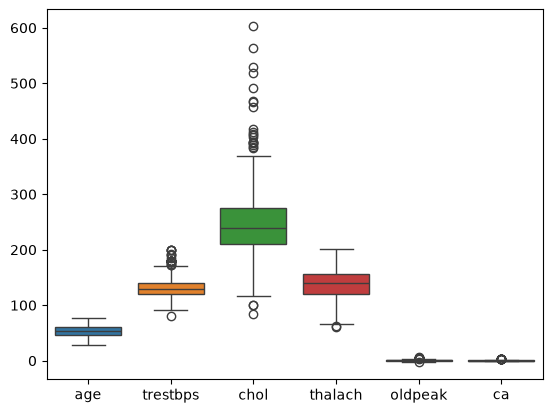

In [1165]:
features = attributes.drop(columns=['num'])
num_feats = features[features.select_dtypes(include=[np.number]).columns]
num_feats
sns.boxplot(data=num_feats)

Because of the severity and number of outliers, especially for the cholesterol column, we'll use RobustScaler as it ...

##### Imputing data

We only use the numerical cols and the binary cols for KNNImputer because it can't take categorical columns and we don't want to arbitrarily change multi-class nominal columns to ordinal ones because that messes up the Euclidean distance math...

In [1166]:
cat_cols = ['cp', 'restecg', 'slope', 'thal']
att_num_only = attributes.drop(columns=cat_cols)
att_num_only
print(df['fbs'].isna().mean())

0.09694989106753812


In [1167]:
# scale and impute the data
robust_scaler = RobustScaler()
r_scaled_data = robust_scaler.fit_transform(att_num_only)
imputer = KNNImputer(weights='distance')
imputed_scaled_data = imputer.fit_transform(r_scaled_data)

# transform back to original scale
original_scale_data = robust_scaler.inverse_transform(imputed_scaled_data)
att_num_imputed = pd.DataFrame(original_scale_data, columns=att_num_only.columns)

# round imputed values for fbs and exang columns to whole number as values should be 0 or 1 only
att_num_imputed['fbs'] = att_num_imputed['fbs'].round(0).astype(int)
att_num_imputed['exang'] = att_num_imputed['exang'].round(0).astype(int)

att_num_imputed

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num
0,63.0,1.0,145.000000,233.0,1,150.000000,0,2.300000,0.000000,0.0
1,67.0,1.0,160.000000,286.0,0,108.000000,1,1.500000,3.000000,2.0
2,67.0,1.0,120.000000,229.0,0,129.000000,1,2.600000,2.000000,1.0
3,37.0,1.0,130.000000,250.0,0,187.000000,0,3.500000,0.000000,0.0
4,41.0,0.0,130.000000,204.0,0,172.000000,0,1.400000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
913,54.0,0.0,127.000000,333.0,1,154.000000,0,0.000000,0.578061,1.0
914,62.0,1.0,142.352941,139.0,0,126.764706,1,1.323529,0.245406,0.0
915,55.0,1.0,122.000000,223.0,1,100.000000,0,0.000000,1.181393,2.0
916,58.0,1.0,131.545108,385.0,1,140.561936,0,1.140047,0.913932,0.0


In [1168]:
# verify fbs and exang only contain 0s or 1s
print(att_num_imputed['fbs'].value_counts())
print(f'\n{att_num_imputed['exang'].value_counts()}')

fbs
0    754
1    164
Name: count, dtype: int64

exang
0    562
1    356
Name: count, dtype: int64


In [1169]:
# check if there are any missing values left
att_num_imputed.isna().sum()

age         0
sex         0
trestbps    0
chol        0
fbs         0
thalach     0
exang       0
oldpeak     0
ca          0
num         0
dtype: int64

In [1170]:
# put the imputed cols together with the other cols that weren't included in the imputation process
cols_imputed = ['trestbps', 'chol', 'fbs', 'exang', 'thalach', 'oldpeak']
df_replace = att_num_imputed[cols_imputed]
df_replace.index = attributes.index
df = df.fillna(df_replace)
df

,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,1,63,1,Cleveland,typical angina,145.000000,233.0,1,lv hypertrophy,150.000000,0,2.300000,downsloping,0.0,fixed defect,0
1,2,67,1,Cleveland,asymptomatic,160.000000,286.0,0,lv hypertrophy,108.000000,1,1.500000,flat,3.0,normal,2
2,3,67,1,Cleveland,asymptomatic,120.000000,229.0,0,lv hypertrophy,129.000000,1,2.600000,flat,2.0,reversable defect,1
3,4,37,1,Cleveland,non-anginal,130.000000,250.0,0,normal,187.000000,0,3.500000,downsloping,0.0,normal,0
4,5,41,0,Cleveland,atypical angina,130.000000,204.0,0,lv hypertrophy,172.000000,0,1.400000,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,0,VA Long Beach,asymptomatic,127.000000,333.0,1,st-t abnormality,154.000000,0,0.000000,NaN,NaN,NaN,1
916,917,62,1,VA Long Beach,typical angina,142.352941,139.0,0,st-t abnormality,126.764706,1,1.323529,NaN,NaN,NaN,0
917,918,55,1,VA Long Beach,asymptomatic,122.000000,223.0,1,st-t abnormality,100.000000,0,0.000000,NaN,NaN,fixed defect,2
918,919,58,1,VA Long Beach,asymptomatic,131.545108,385.0,1,lv hypertrophy,140.561936,0,1.140047,NaN,NaN,NaN,0


In [1171]:
# check if there are any missing values left
df.isna().sum()

id            0
age           0
sex           0
origin        0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope       308
ca          609
thal        484
num           0
dtype: int64

#### 3. features that are missing a significant percentage of their values

In [1172]:
print('Count of missing SLOPE by origin')
df_na_slope = df[df['slope'].isna()]
print(df_na_slope['origin'].value_counts())

print('\nCount of missing CA by origin')
df_na_ca = df[df['ca'].isna()]
print(df_na_ca['origin'].value_counts())

print('\nCount of missing THAL by origin')
df_na_thal = df[df['thal'].isna()]
print(df_na_thal['origin'].value_counts())

Count of missing SLOPE by origin
origin
Hungary          188
VA Long Beach    102
Switzerland       17
Cleveland          1
Name: count, dtype: int64

Count of missing CA by origin
origin
Hungary          289
VA Long Beach    198
Switzerland      117
Cleveland          5
Name: count, dtype: int64

Count of missing THAL by origin
origin
Hungary          264
VA Long Beach    166
Switzerland       51
Cleveland          3
Name: count, dtype: int64


Because slope, thal, and ca are missing in 33-66% of the data, I'm going to try removing these columns from the dataframe. 

These values are typically missing in certain locations, indicating possible differences in hospital protocols. If this model is to be used in places outside of Cleveland, then we need to train the model on features that are commonly collected across almost every clinic in the world and we don't want to risk it overlearning hospital-specific protocols and using that to predict heart disease instead of the actual biology.

Additionally, slope is essentially recorded in the oldpeak feature as the amount in mm by which the ST segment is depressed. While oldpeak only accounts for flat (0) or downslope (>0) and not upslope, upslope doesn't indicate myocardial ischemia as well as a downslope, so not including slope is fine because we have oldpeak.

If we wanted to later, we can compare performance of a model that doesn't use these columns at all vs a model that treats these columns as clinically vital (keeps them).

In [1173]:
df_no_sct = df.drop(columns=['slope', 'ca', 'thal'], inplace=False)

### Check for Imbalances

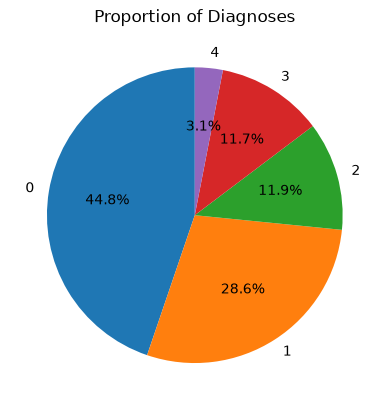

In [1174]:
diagnosis_counts = df['num'].value_counts()
plt.pie(diagnosis_counts, autopct='%1.1f%%', startangle=90, labels=diagnosis_counts.index)
plt.title('Proportion of Diagnoses')
plt.show()

As severity of heart disease goes up, the number of samples goes down. This will make it hard for the neural network to learn how to accurately categorize heart disease severity. But if we combine categories 1-4 (all the categories with heart disease) and turn this into a binary classification problem (is heart disease present or not?), we can potentially enhance model performance as we will have more samples for "heart disease present". Class imbalance is actually relatively lower when we combine the "heart disease present" categories.

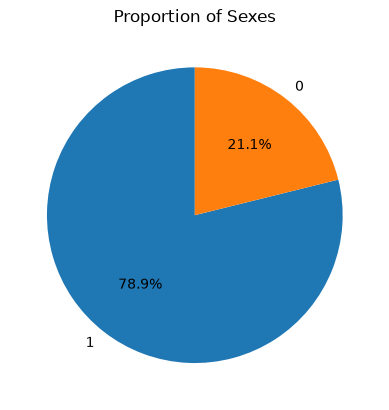

In [1175]:
sex_counts = df['sex'].value_counts()
plt.pie(sex_counts, autopct='%1.1f%%', startangle=90, labels=sex_counts.index)
plt.title('Proportion of Sexes')
plt.show()

There are way more males (1) than females (0) in this dataset. Since males and females with heart disease may have different symptoms/indicators, this imbalance may affect the neural network's accuracy in predicting heart disease.

### How do the features correlate with the target? Are there redundant or highly collinear features?

In [1176]:
# do only for df_no_sct b/c the answer to these questions only matter if we're including them in the model

# TODO must encode categorical columns into numerical format before running any of these statistical checks
# multi-class nominal columns (categorical with no order/ranking): cp, restecg 
    # (use one-hot encoding w/c converts multi-class categories into binary columns, each column representing one class of a category, use this b/c we're using a neural network w/c is a non-tree model...other option is label encoding w/c assigns each category a unique integer w/c introduces implicit order w/c can be misinterpreted by non-tree models when used w/ nominal data) https://www.geeksforgeeks.org/machine-learning/categorical-data-encoding-techniques-in-machine-learning/

# ordinal columns (categorical with order/ranking): none to be included in model

# binary columns (2 options only): sex, exang, fbs (converted to 0s and 1s, no problem)

cat_encoded = pd.get_dummies(df_no_sct[['cp', 'restecg']], dtype=int)
df_eda = df_no_sct.drop(columns=['id', 'origin', 'cp', 'restecg'])
df_eda = pd.concat([df_eda, cat_encoded], axis=1)
df_eda.loc[df_eda['num'] > 1, 'num'] = 1
df_eda

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality
0,63,1,145.000000,233.0,1,150.000000,0,2.300000,0,0,0,0,1,1,0,0
1,67,1,160.000000,286.0,0,108.000000,1,1.500000,1,1,0,0,0,1,0,0
2,67,1,120.000000,229.0,0,129.000000,1,2.600000,1,1,0,0,0,1,0,0
3,37,1,130.000000,250.0,0,187.000000,0,3.500000,0,0,0,1,0,0,1,0
4,41,0,130.000000,204.0,0,172.000000,0,1.400000,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.000000,333.0,1,154.000000,0,0.000000,1,1,0,0,0,0,0,1
916,62,1,142.352941,139.0,0,126.764706,1,1.323529,0,0,0,0,1,0,0,1
917,55,1,122.000000,223.0,1,100.000000,0,0.000000,1,1,0,0,0,0,0,1
918,58,1,131.545108,385.0,1,140.561936,0,1.140047,0,1,0,0,0,1,0,0


#### Correlation Heatmap

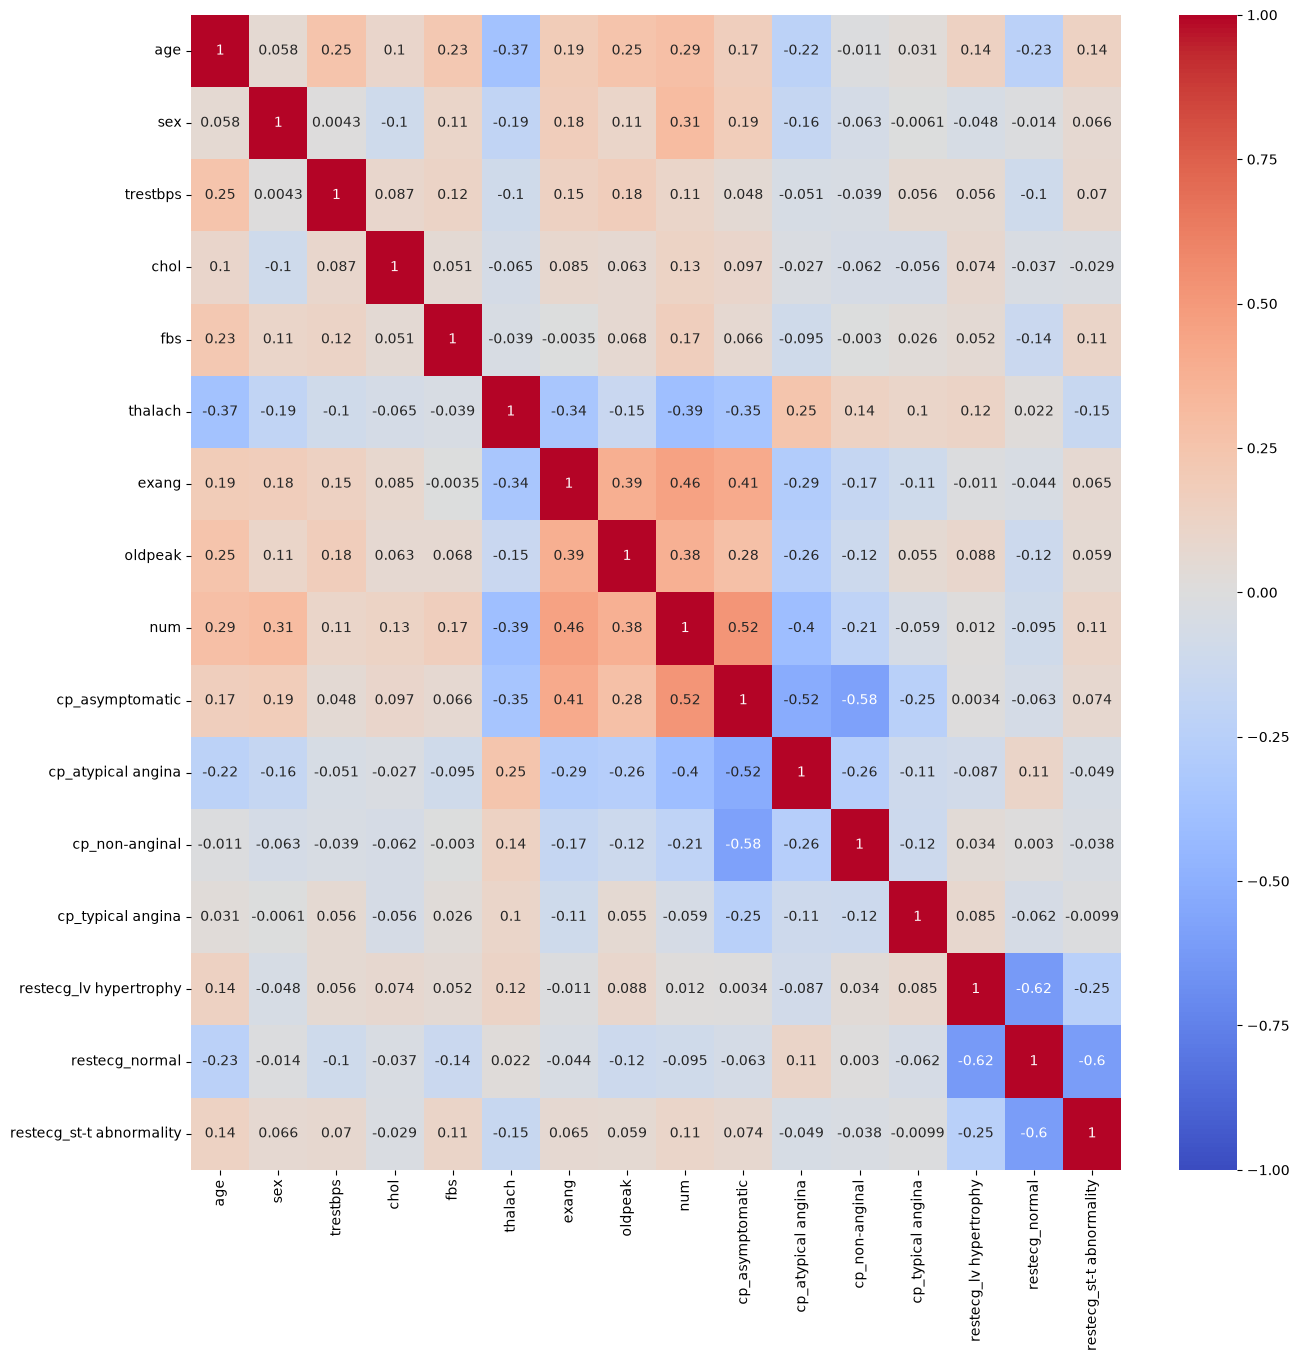

In [1177]:
corr_matrix = df_eda[list(df_eda.columns)].corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

##### Interpretation

- Oldpeak, cp_asymptomatic, exang, and age are positively correlated with the diagnosis num, meaning as they increase/are present, chances of being positive for heart disease go *up*. Meanwhile, thalach and cp_atypical angina are negatively correlated with the diagnosis, meaning as they increase/are present, chances of being positive for heart disease go *down*.
- For the encoded columns like cp and restecg, each different category of cp is strongly negatively correlated with each other and the same for each different category of restecg because a patient can only have 1 of each type (e.g. cannot have both asymptomatic chest pain and typical angina or both normal resting ECG and a resting ECG showing lv hypertrophy.)
- None of the independent features are very highly correlated with each other (no correlations above +/-0.5), so there are no severe redundancies/pairwise (1v1) collinearities.

#### Split violin plot + Mann-Whitney U test for continuous variables

Split by heart disease positive and negative.

##### Scale values for violin plot

In [1178]:
cat_prefixes = ('restecg_', 'cp_')
cat_cols_encoded = [col for col in df_eda.columns if col.startswith(cat_prefixes)]
cat_cols_encoded.extend(['num', 'sex', 'exang', 'fbs'])
df_cont = df_eda.drop(columns=cat_cols_encoded)
scaled_cont_data = pd.DataFrame(robust_scaler.fit_transform(df_cont), columns=df_cont.columns)
scaled_cont_data

,age,trestbps,chol,thalach,oldpeak
0,0.692308,0.750000,-0.112903,0.291667,1.133333
1,1.000000,1.500000,0.741935,-0.875000,0.600000
2,1.000000,-0.500000,-0.177419,-0.291667,1.333333
3,-1.307692,0.000000,0.161290,1.319444,1.933333
4,-1.000000,0.000000,-0.580645,0.902778,0.533333
...,...,...,...,...,...
913,0.000000,-0.150000,1.500000,0.402778,-0.400000
914,0.615385,0.617647,-1.629032,-0.353758,0.482353
915,0.076923,-0.400000,-0.274194,-1.097222,-0.400000
916,0.307692,0.077255,2.338710,0.029498,0.360031


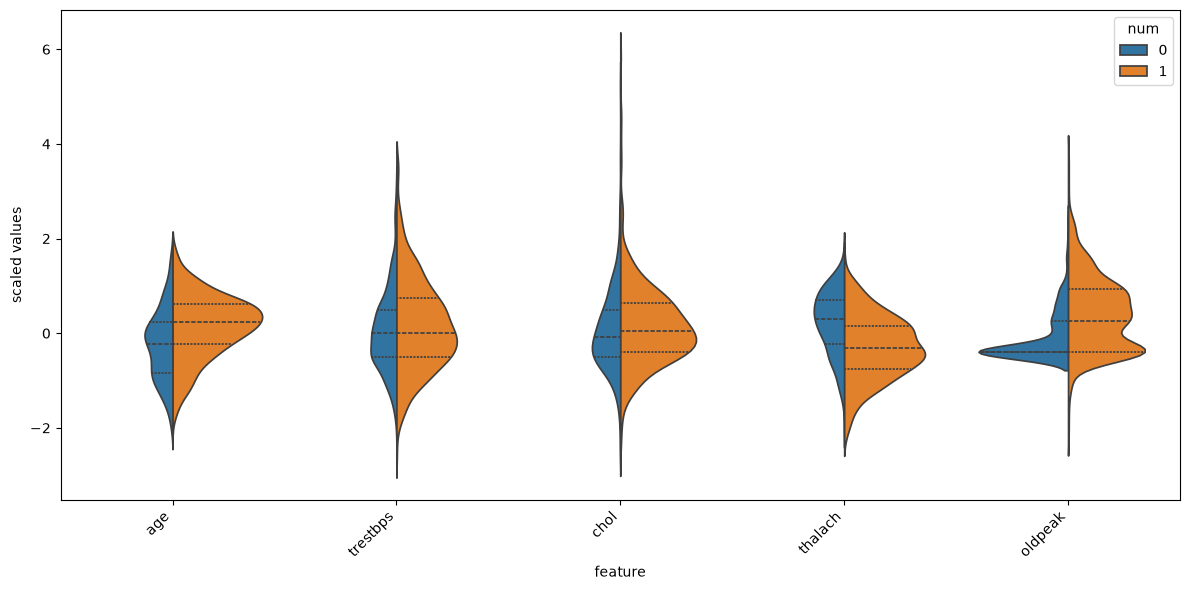

In [1179]:
plt.figure(figsize=(12,6))

v_data = pd.concat([scaled_cont_data, df_eda['num']], axis=1)
long_df_cont = v_data.melt(id_vars='num', var_name='feature', value_name='scaled values')

v_plot = sns.violinplot(data=long_df_cont, x='feature', y='scaled values', hue='num', split=True, inner='quart', hue_order=[0, 1])
# 'Heart Disease Absent', 'Heart Disease Present'
# make x axis labels diagonal for both plots
plt.xticks(rotation=45, ha='right')

ticks = v_plot.get_xticks()
v_plot.set_xticks(ticks)
v_plot.set_xticklabels(v_plot.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [1180]:
print("--- P-values for Continuous Variables ---")
for col in scaled_cont_data.columns:
    stats, pvalue = mannwhitneyu(df_eda.loc[df_eda['num'] == 0, col], df_eda.loc[df_eda['num'] == 1, col])
    print(f"{col} : {pvalue}")

--- P-values for Continuous Variables ---
age : 7.827259752112663e-19
trestbps : 0.002808816479791308
chol : 5.555610726382834e-06
thalach : 5.3324013557160216e-33
oldpeak : 4.870115150376068e-34


##### Interpretation

Each of the continuous variables can statistically significantly distinguish between heart disease positive and heart disease negative diagnoses, but:
- Oldpeak and thalach, each on their own, strongly distinguish between a positive and negative heart disease diagnosis.
- Cholesterol and resting bp, each on their own, weakly distinguish between a positive and negative heart disease diagnosis with cholesterol having severe outliers.
- Age on its own moderately distinguishes between a positive and negative heart disease diagnosis.


#### Grouped bar plot + Chi square test for categorical variables

In [1181]:
# cat_cols_encoded.remove('num')

In [1182]:
df_eda[cat_cols_encoded]

,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,num,sex,exang,fbs
0,0,0,0,1,1,0,0,0,1,0,1
1,1,0,0,0,1,0,0,1,1,1,0
2,1,0,0,0,1,0,0,1,1,1,0
3,0,0,1,0,0,1,0,0,1,0,0
4,0,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
915,1,0,0,0,0,0,1,1,0,0,1
916,0,0,0,1,0,0,1,0,1,1,0
917,1,0,0,0,0,0,1,1,1,0,1
918,1,0,0,0,1,0,0,0,1,0,1


In [1183]:
cat_cols = [c for c in cat_cols_encoded if c != 'num']

cat_counts = df_eda.groupby('num')[cat_cols].sum().reset_index()

long_df_cat = cat_counts.melt(id_vars='num', var_name='feature', value_name='count')

cat_counts

,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,sex,exang,fbs
0,0,104,150,131,26,82,268,61,267,58,44
1,1,391,24,73,19,106,283,118,457,298,120


In [1184]:
# long_df_cat['num'].astype(str)
long_df_cat

,num,feature,count
0,0,cp_asymptomatic,104
1,1,cp_asymptomatic,391
2,0,cp_atypical angina,150
3,1,cp_atypical angina,24
4,0,cp_non-anginal,131
5,1,cp_non-anginal,73
6,0,cp_typical angina,26
7,1,cp_typical angina,19
8,0,restecg_lv hypertrophy,82
9,1,restecg_lv hypertrophy,106


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'cp_asymptomatic'),
  Text(1, 0, 'cp_atypical angina'),
  Text(2, 0, 'cp_non-anginal'),
  Text(3, 0, 'cp_typical angina'),
  Text(4, 0, 'restecg_lv hypertrophy'),
  Text(5, 0, 'restecg_normal'),
  Text(6, 0, 'restecg_st-t abnormality'),
  Text(7, 0, 'sex'),
  Text(8, 0, 'exang'),
  Text(9, 0, 'fbs')])

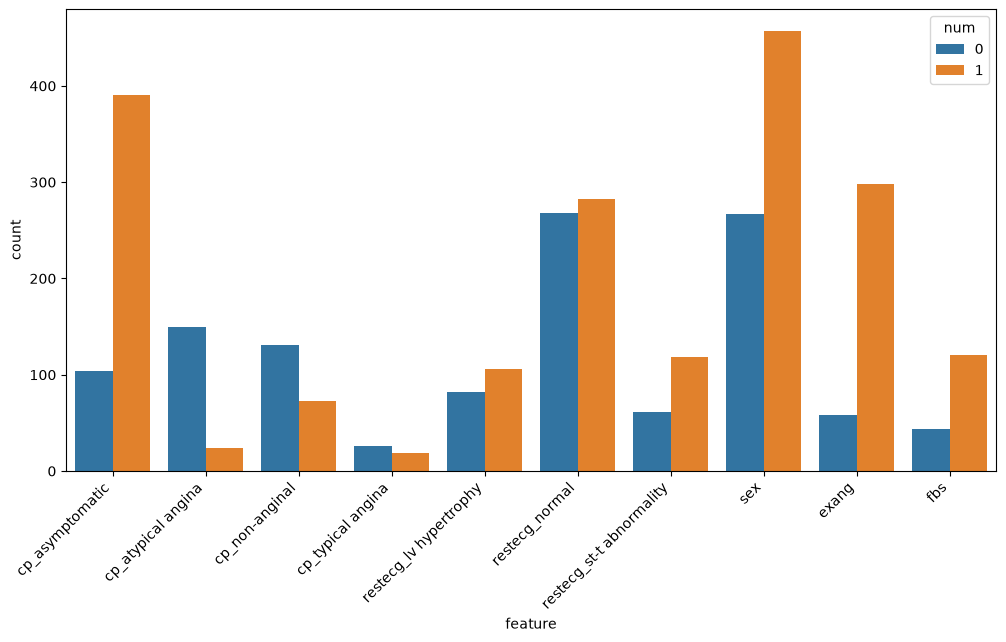

In [1185]:
plt.figure(figsize=(12,6))
bar_plot = sns.barplot(data=long_df_cat, x='feature', y='count', hue='num', hue_order=[0, 1])

plt.xticks(rotation=45, ha='right')

In [1186]:
cat_chi = ['cp', 'restecg', 'sex', 'exang', 'fbs']
df[cat_chi]

,cp,restecg,sex,exang,fbs
0,typical angina,lv hypertrophy,1,0,1
1,asymptomatic,lv hypertrophy,1,1,0
2,asymptomatic,lv hypertrophy,1,1,0
3,non-anginal,normal,1,0,0
4,atypical angina,lv hypertrophy,0,0,0
...,...,...,...,...,...
915,asymptomatic,st-t abnormality,0,0,1
916,typical angina,st-t abnormality,1,1,0
917,asymptomatic,st-t abnormality,1,0,1
918,asymptomatic,lv hypertrophy,1,0,1


In [1187]:
for col in cat_chi:
    contingency_table = pd.crosstab(df[col], df_eda['num'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f'P-value: {p}\n')

num                0    1
cp                       
asymptomatic     104  391
atypical angina  150   24
non-anginal      131   73
typical angina    26   19
P-value: 7.892218723373816e-58

num                 0    1
restecg                   
lv hypertrophy     82  106
normal            268  283
st-t abnormality   61  118
P-value: 0.0028628414475911136

num    0    1
sex          
0    144   50
1    267  457
P-value: 3.2860415875307906e-20

num      0    1
exang          
0      353  209
1       58  298
P-value: 5.6256791878363284e-43

num    0    1
fbs          
0    367  387
1     44  120
P-value: 5.389504581163139e-07



##### Interpretation

The categorical variables of chest pain, resting ECG, sex, exang, and fbs can all statistically significantly distinguish between heart disease positive and negative diagnoses, especially:
- chest pain, particularly asymptomatic and atypical angina
- sex
- exang
- fbs

#### Feature Importance Plot

We can either do this by statistical filtering (e.g. sklearn's chi2) or we can use a surrogate model strategy. Since we want something that can consider multiple features at once and any interactions (multivariate) rather than something that only considers one feature at a time (univariate), we will go with the surrogate model strategy. Since XGBoost Classification was listed as the most accurate and precise model for this dataset on UCI, we will use that as our surrogate.

In [1188]:
obj_dtype = ['sex', 'exang', 'fbs']
df_eda[obj_dtype] = df[obj_dtype].astype('int')

In [1189]:
X = df_eda.drop(columns=['num', 'restecg_normal', 'restecg_st-t abnormality', 'restecg_lv hypertrophy'])
# X = df_eda.drop(columns=['num'])
# X = df_eda[['chol', 'thalach', 'age', 'trestbps', 'oldpeak']]
y = df_eda['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Accuracy:  0.782608695652174


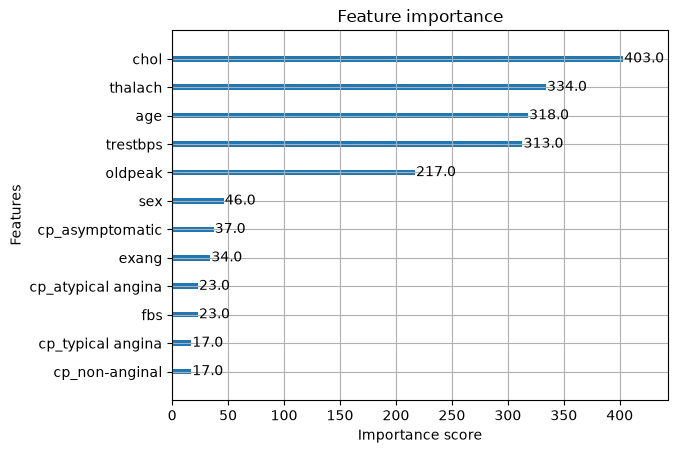

In [1190]:
# create and train model
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

# predict and evaluate
y_pred = xgb.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))

# plot feature importances
plot_importance(xgb)
plt.show()

##### Check for overfitting

In [1191]:
test_preds = xgb.predict(X_test)
train_preds = xgb.predict(X_train)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}\n")

Train accuracy: 1.0000
Test accuracy: 0.7826



##### Interpretation

According to the feature importance plot, the most important features are chol, thalach, age, trestbps, and oldpeak. But when I use only these columns as the features, accuracy drops to 70% from 76-77% if I use all the features in df_eda or 79-80% if I drop just the restecg feature (because it's the least statistically significant categorical column).

## Training

In [ ]:
# len(X.columns) = in_features = 12
# out_features = 1 even if there are two possibilities for heart disease diagnosis (0 or 1) b/c this is not a multi-class problem; it's a single-class problem with 2 options

''' choosing how many neurons in hidden layer:

Common Rules of Thumb
- Set the number between the size of the input layer and the size of the output layer.
- Use two-thirds of the input layer size plus the output layer size.
- Keep the number below twice the size of the input layer.

'''
class Model(nn.Module):
    def __init__(self, in_features=len(X.columns), h1=10, h2=10, out_features=1):
        # instantiate our nn.Module
        super().__init__()

        # create fully-connected layers
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        # feed data (x), then output of each layer (x) into feed-forward function...
        x = F.relu(self.fc1(x))  # feed data into hidden layer 1
        x = F.relu(self.fc2(x))  # feed data from hidden layer 1 into hidden layer 2
        x = torch.sigmoid(self.out(x))  # feed the raw logits in self.out(x) into sigmoid function which returns 0 or 1; the output represents the probability of the positive class

        return x

## Model Explainability

Once your PyTorch model is trained, you will likely want to extract feature importances or use explainability tools like SHAP (SHapley Additive exPlanations) to see what your network learned.